In [8]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
x,y = make_moons(n_samples=300, noise= 0.05, random_state= 23)

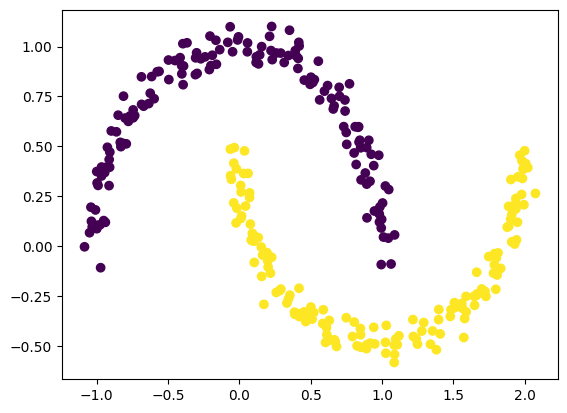

In [7]:
plt.scatter(x[:,0],x[:,1], c = y)

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.30, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)

In [25]:
svc = SVC(kernel='rbf', C = 10)

In [26]:
svc.fit(x_train_scale,y_train)

SVC(C=10)

In [27]:
y_train_pred = svc.predict(x_train_scale)

In [28]:
x_train_scale.shape

(210, 2)

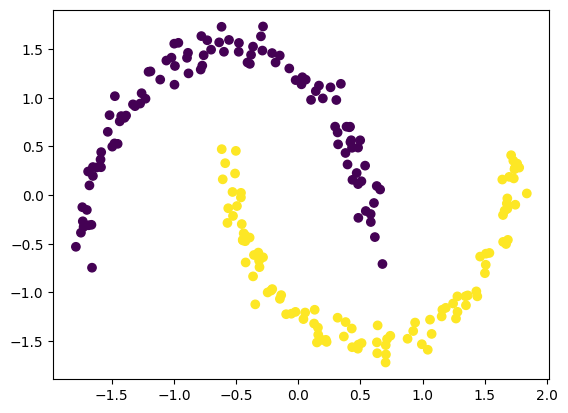

In [29]:
plt.scatter(x_train_scale[:,0],x_train_scale[:,1], c = y_train_pred)

In [39]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [43]:
dataset = load_breast_cancer()

In [44]:
x = dataset.data

In [45]:
y = dataset.target

In [46]:
x = pd.DataFrame(x, columns = dataset.feature_names)
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [86]:
pipeline = Pipeline([('estimator',None)])

param_grid = [{'estimator': [LogisticRegression()]},
              {'estimator': [DecisionTreeClassifier()]},
              {'estimator': [RandomForestClassifier()]},
              {'estimator': [SVC()],
              'estimator__C': [1,2,3,5,8,10],
              'estimator__kernel': ['linear','rbf']}]
grid_search = GridSearchCV(pipeline,param_grid, cv = 5, scoring='accuracy',verbose=1)

In [87]:
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size=0.30,random_state=42)

In [88]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

GridSearchCV(cv=5, estimator=Pipeline(steps=[('estimator', None)]),
             param_grid=[{'estimator': [LogisticRegression()]},
                         {'estimator': [DecisionTreeClassifier()]},
                         {'estimator': [RandomForestClassifier()]},
                         {'estimator': [SVC()],
                          'estimator__C': [1, 2, 3, 5, 8, 10],
                          'estimator__kernel': ['linear', 'rbf']}],
             scoring='accuracy', verbose=1)

In [89]:
grid_search.best_score_

np.float64(0.9647784810126583)

In [90]:
grid_search.best_params_

{'estimator': SVC(), 'estimator__C': 10, 'estimator__kernel': 'linear'}

In [94]:
grid_search

GridSearchCV(cv=5, estimator=Pipeline(steps=[('estimator', None)]),
             param_grid=[{'estimator': [LogisticRegression()]},
                         {'estimator': [DecisionTreeClassifier()]},
                         {'estimator': [RandomForestClassifier()]},
                         {'estimator': [SVC()],
                          'estimator__C': [1, 2, 3, 5, 8, 10],
                          'estimator__kernel': ['linear', 'rbf']}],
             scoring='accuracy', verbose=1)